# 04 — Bias Detection
Ανίχνευση μεροληψίας και στα τρία μοντέλα με Demographic Parity και Disparate Impact.
Ορισμός υποομάδων βάσει χαρακτηριστικών του HELOC dataset.

## 1. Εισαγωγή βιβλιοθηκών

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
from sklearn.metrics import roc_auc_score
import joblib
from xgboost import XGBClassifier
from tensorflow import keras
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print("Βιβλιοθήκες φορτώθηκαν επιτυχώς.")

Βιβλιοθήκες φορτώθηκαν επιτυχώς.


## 2. Φόρτωση δεδομένων και μοντέλων

In [14]:
DATA_DIR = '../data/processed'

X_test        = np.load(f'{DATA_DIR}/X_test.npy')
y_test        = np.load(f'{DATA_DIR}/y_test.npy')
X_test_scaled = np.load(f'{DATA_DIR}/X_test_scaled.npy')
feature_names = np.load(f'{DATA_DIR}/feature_names.npy', allow_pickle=True)

lr_model  = joblib.load('../data/models/lr_model.pkl')
xgb_model = XGBClassifier()
xgb_model.load_model('../data/models/xgb_model.json')
ffnn_model = keras.models.load_model('../data/models/ffnn_model.keras')

print("Δεδομένα και μοντέλα φορτώθηκαν επιτυχώς.")

Δεδομένα και μοντέλα φορτώθηκαν επιτυχώς.


## 3. Ορισμός Υποομάδων
Το HELOC δεν περιέχει δημογραφικά στοιχεία (φύλο, εθνικότητα).
Ορίζουμε υποομάδες βάσει πιστωτικού ιστορικού:
- Ομάδα Α: δανειολήπτες με λίγο ιστορικό (AverageMInFile < διάμεσος)
- Ομάδα Β: δανειολήπτες με πολύ ιστορικό (AverageMInFile >= διάμεσος)

In [15]:
# το HELOC δεν έχει δημογραφικά features — χρησιμοποιώ AverageMInFile
# (μήκος πιστωτικού ιστορικού) ως proxy, μόνο για demonstration
# Εύρεση index του AverageMInFile
avg_m_idx = list(feature_names).index('AverageMInFile')

# Ορισμός υποομάδων βάσει διαμέσου
median_avg_m = np.median(X_test[:, avg_m_idx])
sensitive_feature = (X_test[:, avg_m_idx] >= median_avg_m).astype(int)

print(f"Διάμεσος AverageMInFile: {median_avg_m:.1f} μήνες")
print(f"Ομάδα Α (λίγο ιστορικό, <{median_avg_m:.0f} μήνες): {(sensitive_feature==0).sum()} εγγραφές")
print(f"Ομάδα Β (πολύ ιστορικό, >={median_avg_m:.0f} μήνες): {(sensitive_feature==1).sum()} εγγραφές")

Διάμεσος AverageMInFile: 76.0 μήνες
Ομάδα Α (λίγο ιστορικό, <76 μήνες): 737 εγγραφές
Ομάδα Β (πολύ ιστορικό, >=76 μήνες): 743 εγγραφές


## 4. Προβλέψεις και από τα τρία μοντέλα

In [16]:
# Προβλέψεις
lr_pred   = lr_model.predict(X_test_scaled)
xgb_pred  = xgb_model.predict(X_test)
ffnn_pred = (ffnn_model.predict(X_test_scaled, verbose=0).flatten() >= 0.5).astype(int)

print("Προβλέψεις ολοκληρώθηκαν.")
print(f"LR   — Bad predictions: {lr_pred.sum()} ({lr_pred.mean()*100:.1f}%)")
print(f"XGB  — Bad predictions: {xgb_pred.sum()} ({xgb_pred.mean()*100:.1f}%)")
print(f"FFNN — Bad predictions: {ffnn_pred.sum()} ({ffnn_pred.mean()*100:.1f}%)")

Προβλέψεις ολοκληρώθηκαν.
LR   — Bad predictions: 783 (52.9%)
XGB  — Bad predictions: 798 (53.9%)
FFNN — Bad predictions: 790 (53.4%)


## 5. Bias Detection — Demographic Parity & Disparate Impact

In [17]:
def compute_bias_metrics(y_true, y_pred, sensitive, model_name):
    # Demographic Parity Difference
    dpd = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive)
    
    # Disparate Impact
    approval_a = (y_pred[sensitive == 0] == 0).mean()  # Good predictions για ομάδα Α
    approval_b = (y_pred[sensitive == 1] == 0).mean()  # Good predictions για ομάδα Β
    di = min(approval_a, approval_b) / max(approval_a, approval_b)
    
    print(f"{'='*45}")
    print(f"  {model_name}")
    print(f"{'='*45}")
    print(f"  Ποσοστό έγκρισης Ομάδα Α (λίγο ιστορικό): {approval_a*100:.1f}%")
    print(f"  Ποσοστό έγκρισης Ομάδα Β (πολύ ιστορικό): {approval_b*100:.1f}%")
    print(f"  Demographic Parity Difference: {dpd:.4f}")
    print(f"  Disparate Impact Ratio:        {di:.4f}")
    if di >= 0.8:
        print(f"  → Αποδεκτό (DI >= 0.8)")
    else:
        print(f"  → Προβληματικό (DI < 0.8)")
    print()
    
    return {'model': model_name, 'DPD': dpd, 'DI': di,
            'approval_A': approval_a, 'approval_B': approval_b}

# Υπολογισμός για όλα τα μοντέλα
lr_bias   = compute_bias_metrics(y_test, lr_pred, sensitive_feature, "Logistic Regression")
xgb_bias  = compute_bias_metrics(y_test, xgb_pred, sensitive_feature, "XGBoost")
ffnn_bias = compute_bias_metrics(y_test, ffnn_pred, sensitive_feature, "FFNN")

  Logistic Regression
  Ποσοστό έγκρισης Ομάδα Α (λίγο ιστορικό): 30.1%
  Ποσοστό έγκρισης Ομάδα Β (πολύ ιστορικό): 63.9%
  Demographic Parity Difference: 0.3381
  Disparate Impact Ratio:        0.4712
  → Προβληματικό (DI < 0.8)

  XGBoost
  Ποσοστό έγκρισης Ομάδα Α (λίγο ιστορικό): 29.6%
  Ποσοστό έγκρισης Ομάδα Β (πολύ ιστορικό): 62.4%
  Demographic Parity Difference: 0.3287
  Disparate Impact Ratio:        0.4737
  → Προβληματικό (DI < 0.8)

  FFNN
  Ποσοστό έγκρισης Ομάδα Α (λίγο ιστορικό): 30.4%
  Ποσοστό έγκρισης Ομάδα Β (πολύ ιστορικό): 62.7%
  Demographic Parity Difference: 0.3233
  Disparate Impact Ratio:        0.4846
  → Προβληματικό (DI < 0.8)



### 5.1 Οπτικοποίηση Bias

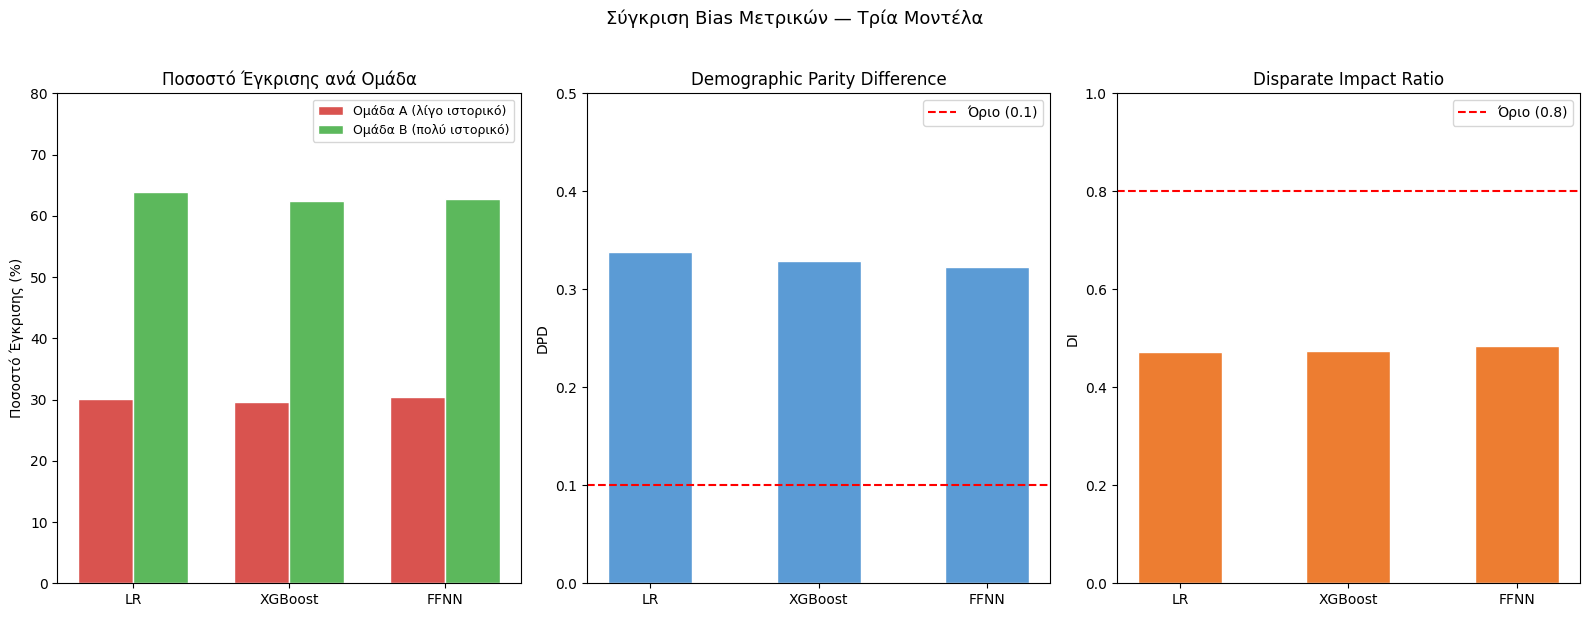

Αποθηκεύτηκε: figures/12_bias_comparison.png


In [18]:
bias_df = pd.DataFrame([lr_bias, xgb_bias, ffnn_bias])

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Γράφημα 1: Ποσοστά έγκρισης ανά ομάδα
x = np.arange(3)
width = 0.35
models = ['LR', 'XGBoost', 'FFNN']

axes[0].bar(x - width/2, bias_df['approval_A']*100, width, 
            label='Ομάδα Α (λίγο ιστορικό)', color='#d9534f', edgecolor='white')
axes[0].bar(x + width/2, bias_df['approval_B']*100, width,
            label='Ομάδα Β (πολύ ιστορικό)', color='#5cb85c', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylabel('Ποσοστό Έγκρισης (%)')
axes[0].set_title('Ποσοστό Έγκρισης ανά Ομάδα')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 80)

# Γράφημα 2: Demographic Parity Difference
axes[1].bar(models, bias_df['DPD'], color='#5b9bd5', edgecolor='white', width=0.5)
axes[1].axhline(y=0.1, color='red', linestyle='--', label='Όριο (0.1)')
axes[1].set_title('Demographic Parity Difference')
axes[1].set_ylabel('DPD')
axes[1].legend()
axes[1].set_ylim(0, 0.5)

# Γράφημα 3: Disparate Impact Ratio
axes[2].bar(models, bias_df['DI'], color='#ed7d31', edgecolor='white', width=0.5)
axes[2].axhline(y=0.8, color='red', linestyle='--', label='Όριο (0.8)')
axes[2].set_title('Disparate Impact Ratio')
axes[2].set_ylabel('DI')
axes[2].legend()
axes[2].set_ylim(0, 1)

plt.suptitle('Σύγκριση Bias Μετρικών — Τρία Μοντέλα', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/12_bias_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: figures/12_bias_comparison.png")

## 6. Fairness Mitigation
Προσπάθεια μείωσης bias με Fairlearn.
Κεντρικό ερώτημα: πόσο κοστίζει σε AUC η βελτίωση της δικαιοσύνης;

In [19]:
# Φόρτωση train data
X_train_scaled = np.load(f'{DATA_DIR}/X_train_scaled.npy')
y_train        = np.load(f'{DATA_DIR}/y_train.npy')
X_train        = np.load(f'{DATA_DIR}/X_train.npy')

# Sensitive feature για train set
avg_m_idx_train = list(feature_names).index('AverageMInFile')
median_train = np.median(X_train[:, avg_m_idx_train])
sensitive_train = (X_train[:, avg_m_idx_train] >= median_train).astype(int)

print(f"Train sensitive feature — Ομάδα Α: {(sensitive_train==0).sum()}, Ομάδα Β: {(sensitive_train==1).sum()}")

Train sensitive feature — Ομάδα Α: 3432, Ομάδα Β: 3470


In [20]:
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Fairness Mitigation με Logistic Regression ως base estimator
# (ExponentiatedGradient δουλεύει καλύτερα με LR)
base_estimator = LogisticRegression(max_iter=1000, random_state=42)

mitigator = ExponentiatedGradient(
    estimator=base_estimator,
    constraints=DemographicParity(),
    eps=0.01
)

mitigator.fit(
    X_train_scaled, y_train,
    sensitive_features=sensitive_train
)

print("Fairness mitigation ολοκληρώθηκε.")

Fairness mitigation ολοκληρώθηκε.


In [21]:
# Προβλέψεις με mitigated μοντέλο
mitigated_pred = mitigator.predict(X_test_scaled)
mitigated_prob = mitigator._pmf_predict(X_test_scaled)[:, 1]

# Bias metrics πριν και μετά
approval_a_before = (lr_pred[sensitive_feature == 0] == 0).mean()
approval_b_before = (lr_pred[sensitive_feature == 1] == 0).mean()
di_before = min(approval_a_before, approval_b_before) / max(approval_a_before, approval_b_before)

approval_a_after = (mitigated_pred[sensitive_feature == 0] == 0).mean()
approval_b_after = (mitigated_pred[sensitive_feature == 1] == 0).mean()
di_after = min(approval_a_after, approval_b_after) / max(approval_a_after, approval_b_after)

auc_before = roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1])
auc_after  = roc_auc_score(y_test, mitigated_prob)

print("="*50)
print("  Αποτελέσματα Fairness Mitigation")
print("="*50)
print(f"  Disparate Impact — Πριν: {di_before:.4f}")
print(f"  Disparate Impact — Μετά: {di_after:.4f}")
print(f"  Βελτίωση DI:             {di_after - di_before:+.4f}")
print()
print(f"  AUC — Πριν: {auc_before:.4f}")
print(f"  AUC — Μετά: {auc_after:.4f}")
print(f"  Κόστος AUC: {auc_after - auc_before:+.4f}")
print("="*50)

  Αποτελέσματα Fairness Mitigation
  Disparate Impact — Πριν: 0.4712
  Disparate Impact — Μετά: 0.9310
  Βελτίωση DI:             +0.4598

  AUC — Πριν: 0.7894
  AUC — Μετά: 0.6804
  Κόστος AUC: -0.1090


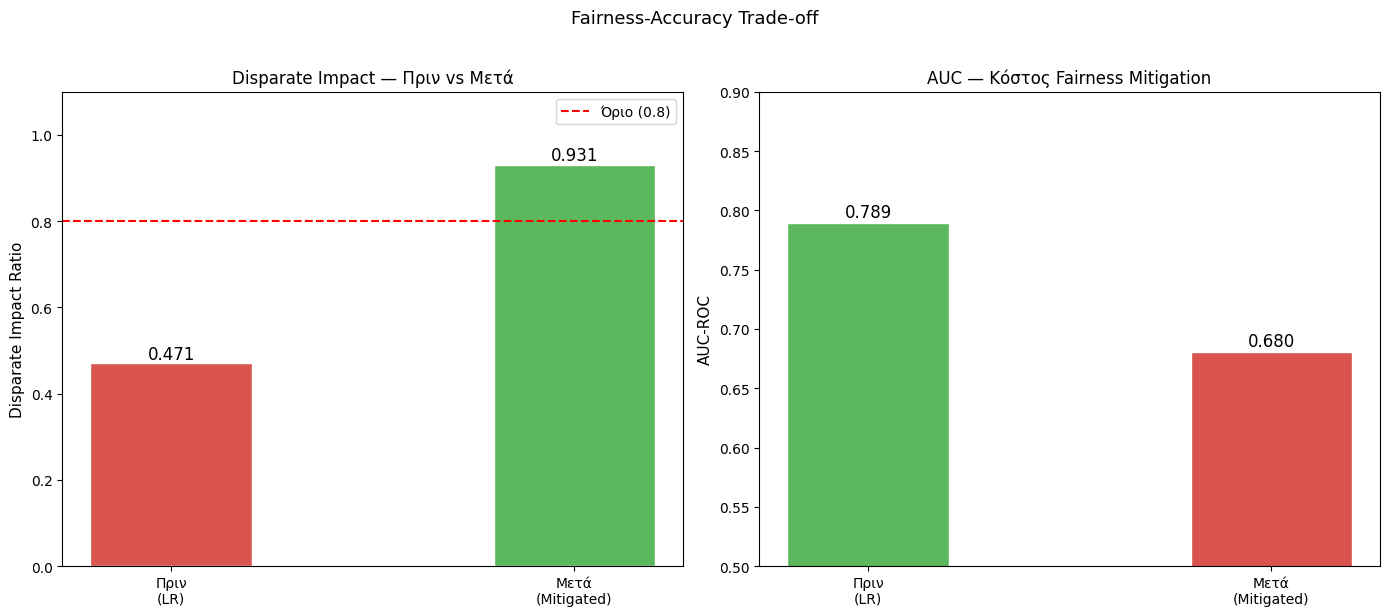

Αποθηκεύτηκε: figures/20_fairness_mitigation.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Γράφημα 1: DI πριν και μετά
categories = ['Πριν\n(LR)', 'Μετά\n(Mitigated)']
di_values = [di_before, di_after]
colors_di = ['#d9534f' if x < 0.8 else '#5cb85c' for x in di_values]

bars = axes[0].bar(categories, di_values, color=colors_di, 
                   edgecolor='white', width=0.4)
axes[0].axhline(y=0.8, color='red', linestyle='--', 
                linewidth=1.5, label='Όριο (0.8)')
for bar, val in zip(bars, di_values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=12)
axes[0].set_ylabel('Disparate Impact Ratio', fontsize=11)
axes[0].set_title('Disparate Impact — Πριν vs Μετά', fontsize=12)
axes[0].set_ylim(0, 1.1)
axes[0].legend(fontsize=10)

# Γράφημα 2: AUC πριν και μετά
auc_values = [auc_before, auc_after]
colors_auc = ['#5cb85c', '#d9534f']

bars = axes[1].bar(categories, auc_values, color=colors_auc,
                   edgecolor='white', width=0.4)
for bar, val in zip(bars, auc_values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=12)
axes[1].set_ylabel('AUC-ROC', fontsize=11)
axes[1].set_title('AUC — Κόστος Fairness Mitigation', fontsize=12)
axes[1].set_ylim(0.5, 0.9)

plt.suptitle('Fairness-Accuracy Trade-off', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/20_fairness_mitigation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Αποθηκεύτηκε: figures/20_fairness_mitigation.png")

## 7. Fairness Mitigation — XGBoost (ThresholdOptimizer)
Post-processing mitigation για το κύριο μοντέλο XGBoost.
Σε αντίθεση με το ExponentiatedGradient (in-processing), το ThresholdOptimizer
δεν αλλάζει το μοντέλο — προσαρμόζει το threshold ανά ομάδα μετά την εκπαίδευση.
Κεντρικό μήνυμα: η μεροληψία μπορεί να αντιμετωπιστεί και post-hoc, αλλά
πάντα με κόστος σε απόδοση.

In [23]:
from sklearn.metrics import balanced_accuracy_score

# βρίσκω διαφορετικό threshold ανά ομάδα ώστε τα approval rates να εξισωθούν

xgb_scores = xgb_model.predict_proba(X_test)[:, 1]

# Scores ανά ομάδα
scores_A = xgb_scores[sensitive_feature == 0]
scores_B = xgb_scores[sensitive_feature == 1]

best_t_A, best_t_B, best_diff = 0.5, 0.5, 1.0
for t_A in np.arange(0.1, 0.9, 0.01):
    for t_B in np.arange(0.1, 0.9, 0.01):
        rate_A = (scores_A < t_A).mean()
        rate_B = (scores_B < t_B).mean()
        diff = abs(rate_A - rate_B)
        if diff < best_diff:
            best_diff, best_t_A, best_t_B = diff, t_A, t_B

print(f"Optimal thresholds — Ομάδα Α: {best_t_A:.2f}, Ομάδα Β: {best_t_B:.2f}")

# Προβλέψεις με τα νέα thresholds
xgb_mitigated_pred = np.zeros(len(xgb_scores), dtype=int)
xgb_mitigated_pred[sensitive_feature == 0] = (scores_A >= best_t_A).astype(int)
xgb_mitigated_pred[sensitive_feature == 1] = (scores_B >= best_t_B).astype(int)

approval_a_xgb_before = (xgb_pred[sensitive_feature == 0] == 0).mean()
approval_b_xgb_before = (xgb_pred[sensitive_feature == 1] == 0).mean()
di_xgb_before = min(approval_a_xgb_before, approval_b_xgb_before) / max(approval_a_xgb_before, approval_b_xgb_before)

approval_a_xgb_after = (xgb_mitigated_pred[sensitive_feature == 0] == 0).mean()
approval_b_xgb_after = (xgb_mitigated_pred[sensitive_feature == 1] == 0).mean()
di_xgb_after = min(approval_a_xgb_after, approval_b_xgb_after) / max(approval_a_xgb_after, approval_b_xgb_after)

bacc_xgb_before = balanced_accuracy_score(y_test, xgb_pred)
bacc_xgb_after  = balanced_accuracy_score(y_test, xgb_mitigated_pred)
auc_xgb         = roc_auc_score(y_test, xgb_scores)

print('=' * 55)
print('  Αποτελέσματα XGBoost Fairness Mitigation')
print('  (Manual ThresholdOptimizer — post-processing)')
print('=' * 55)
print(f'  Disparate Impact — Πριν: {di_xgb_before:.4f}')
print(f'  Disparate Impact — Μετά: {di_xgb_after:.4f}')
print(f'  Βελτίωση DI:             {di_xgb_after - di_xgb_before:+.4f}')
print()
print(f'  Balanced Accuracy — Πριν: {bacc_xgb_before:.4f}')
print(f'  Balanced Accuracy — Μετά: {bacc_xgb_after:.4f}')
print(f'  Κόστος Balanced Acc:      {bacc_xgb_after - bacc_xgb_before:+.4f}')
print()
print(f'  AUC-ROC (αμετάβλητο — scores μοντέλου δεν άλλαξαν): {auc_xgb:.4f}')
print('=' * 55)

Optimal thresholds — Ομάδα Α: 0.70, Ομάδα Β: 0.37
  Αποτελέσματα XGBoost Fairness Mitigation
  (Manual ThresholdOptimizer — post-processing)
  Disparate Impact — Πριν: 0.4737
  Disparate Impact — Μετά: 0.9999
  Βελτίωση DI:             +0.5262

  Balanced Accuracy — Πριν: 0.7231
  Balanced Accuracy — Μετά: 0.7014
  Κόστος Balanced Acc:      -0.0217

  AUC-ROC (αμετάβλητο — scores μοντέλου δεν άλλαξαν): 0.7963


### 7.1 Σύγκριση Mitigation: LR (in-processing) vs XGBoost (post-processing)

  LR Balanced Accuracy — Πριν vs Μετά Mitigation
  (συμπλήρωμα για figure 25 — in-processing)
  Balanced Accuracy — Πριν: 0.7201
  Balanced Accuracy — Μετά: 0.6899
  Κόστος Balanced Acc:      -0.0303


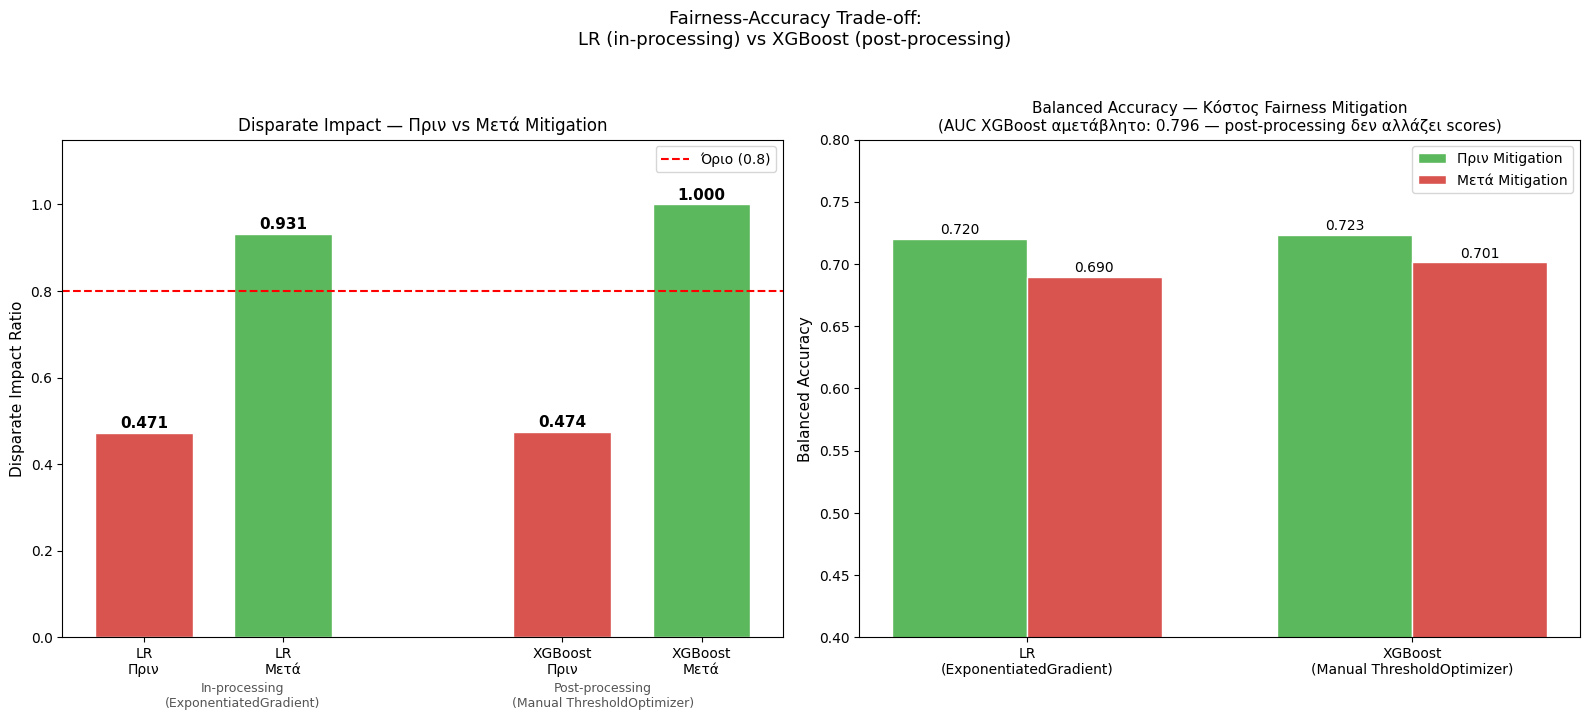

Αποθηκεύτηκε: figures/25_fairness_mitigation_comparison.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# DI πριν και μετά mitigation, LR vs XGBoost
x = [0, 1, 3, 4]  # κενό μεταξύ LR και XGBoost
di_vals = [di_before, di_after, di_xgb_before, di_xgb_after]
labels  = ['LR\nΠριν', 'LR\nΜετά', 'XGBoost\nΠριν', 'XGBoost\nΜετά']
colors_di = ['#d9534f' if v < 0.8 else '#5cb85c' for v in di_vals]

bars0 = axes[0].bar(x, di_vals, color=colors_di, edgecolor='white', width=0.7)
axes[0].axhline(y=0.8, color='red', linestyle='--', linewidth=1.5, label='Όριο (0.8)')
for bar, val in zip(bars0, di_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.012,
                f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=10)
axes[0].set_ylabel('Disparate Impact Ratio', fontsize=11)
axes[0].set_title('Disparate Impact — Πριν vs Μετά Mitigation', fontsize=12)
axes[0].set_ylim(0, 1.15)
axes[0].legend(fontsize=10)

axes[0].annotate('In-processing\n(ExponentiatedGradient)',
                xy=(0.25, -0.14), xycoords='axes fraction',
                ha='center', fontsize=9, color='#555555')
axes[0].annotate('Post-processing\n(Manual ThresholdOptimizer)',
                xy=(0.75, -0.14), xycoords='axes fraction',
                ha='center', fontsize=9, color='#555555')

# balanced accuracy trade-off μετά το mitigation
# χρησιμοποιώ balanced accuracy και για LR ώστε η σύγκριση να είναι ομοιογενής
from sklearn.metrics import balanced_accuracy_score as bas
bacc_lr_before = bas(y_test, lr_pred)
bacc_lr_after  = bas(y_test, mitigated_pred)

print('=' * 55)
print('  LR Balanced Accuracy — Πριν vs Μετά Mitigation')
print('  (συμπλήρωμα για figure 25 — in-processing)')
print('=' * 55)
print(f'  Balanced Accuracy — Πριν: {bacc_lr_before:.4f}')
print(f'  Balanced Accuracy — Μετά: {bacc_lr_after:.4f}')
print(f'  Κόστος Balanced Acc:      {bacc_lr_after - bacc_lr_before:+.4f}')
print('=' * 55)

models_label     = ['LR\n(ExponentiatedGradient)', 'XGBoost\n(Manual ThresholdOptimizer)']
bacc_before_vals = [bacc_lr_before, bacc_xgb_before]
bacc_after_vals  = [bacc_lr_after,  bacc_xgb_after]

xpos  = [0, 1]
width = 0.35

bars_b = axes[1].bar([p - width/2 for p in xpos], bacc_before_vals,
                     width, label='Πριν Mitigation', color='#5cb85c', edgecolor='white')
bars_a = axes[1].bar([p + width/2 for p in xpos], bacc_after_vals,
                     width, label='Μετά Mitigation',  color='#d9534f', edgecolor='white')

for bar, val in zip(bars_b, bacc_before_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.004,
                f'{val:.3f}', ha='center', fontsize=10)
for bar, val in zip(bars_a, bacc_after_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.004,
                f'{val:.3f}', ha='center', fontsize=10)

axes[1].set_xticks(xpos)
axes[1].set_xticklabels(models_label, fontsize=10)
axes[1].set_ylabel('Balanced Accuracy', fontsize=11)
axes[1].set_title('Balanced Accuracy — Κόστος Fairness Mitigation', fontsize=12)
axes[1].set_ylim(0.40, 0.80)
axes[1].legend(fontsize=10)

# Σημείωση ότι AUC αμετάβλητο για XGBoost
axes[1].set_title(
    'Balanced Accuracy — Κόστος Fairness Mitigation\n'
    f'(AUC XGBoost αμετάβλητο: {auc_xgb:.3f} — post-processing δεν αλλάζει scores)',
    fontsize=11
)

plt.suptitle(
    'Fairness-Accuracy Trade-off:\n'
    'LR (in-processing) vs XGBoost (post-processing)',
    fontsize=13, y=1.03
)
plt.tight_layout()
plt.savefig('../figures/25_fairness_mitigation_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print('Αποθηκεύτηκε: figures/25_fairness_mitigation_comparison.png')